# Analysis of the results from MentalManip dataset tests

MentalManip dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [19]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
from datasets import load_dataset
import pandas as pd
from data_loader import load_mentalmanip_dataset

## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


# Zero-shot
### Analysis results zero-shot - manipulation detection

In [21]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_zero_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_manipulation_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_manipulation_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pr

In [22]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_preliminary_zero_shot = run_full_preliminary_analysis(merged_df_zero_shot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS,
                                                              plots_root="results/figs",
                                                              strategy="zero_shot",
                                                              stage="preliminary",
                                                              per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Age Age 4 vs Age 5                  Δ = -1.3 pp
 2. Intersectional White Woman vs Man   Δ = -1.0 pp
 3. Age Age 3 vs Age 4                  Δ = +0.9 pp
 4. Age Age 1 vs Age 5                  Δ = -0.8 pp
 5. Age Age 2 vs Age 4                  Δ = +0.8 pp

Detailed results
[—] man_vs_woman                        | Man: 0.669 | Woman: 0.668
         Δ = +0.1 pp   95% CI [-0.5, +0.8] pp   h = +0.003
[—] asian_vs_black                      | Asian: 0.671 | Black: 0.669
         Δ = +0.3 pp   95% CI [-0.5, +1.1] pp   h = +0.006
[—] asian_vs_indian        

In [23]:
from analysis_1 import run_full_tier1_analysis

result_tier1_zero_shot = run_full_tier1_analysis(merged_df_zero_shot, case=manipulation_case, person_set=PERSON_ETHNICS,
                                        figures=True,
                                        plots_root="results/figs",
                                        strategy="zero_shot", 
                                        stage="tier1",
                                        per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=30,000 | n_items=500 | n_profiles=60
Clustered on: sample_id (n_clusters=500)

-- Block Wald tests --
   - main:C(gender): F(1, 499)=3.7, p=0.05484
   - main:C(ethnicity): F(5, 499)=1.64, p=0.1468
   - inter:C(gender):C(ethnicity): F(5, 499)=1.13, p=0.3437

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=30,000, n_profiles=60, n_items=500
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 3.704374    1 499.0 0.054838
          

In [25]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_zero_shot = run_full_tier2_analysis(
    merged_df=merged_df_zero_shot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="zero_shot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
[INFO] Suppressing low-n values in technique (n<50): Intimidation (n=18), Accusation (n=17), Shaming or Belittlement (n=17), Rationalization (n=9), Shaming or Belittlement,Accusation (n=9), Denial (n=5), Intimidation,Persuasion or Seduction (n=4), Rationalization,Persuasion or Seduction (n=4), Brandishing Anger (n=4), Evasion (n=4), Playing Victim Role (n=3), Feigning Innocence (n=3), Shaming or Belittlement,Brandishing Anger (n=3), Rationalization,Intimidation (n=2), Intimidation,Accusation (n=2), Persuasion or Seduction,Accusation (n=2), Accusation,Persuasion or Seduction (n=2), Brandishing Anger,Persuasion or Seduction (n=2), Evasion,Accusation (n=1), Rationalization,Shaming or Belittlement,Accusation (n=1), Shaming or Belittlement,Pe

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[Selection gap] Δacc(dev) − Δacc(test): +0.0202

=== Cost/Efficiency Pareto (TEST) ===
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum un

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


2. Cluster Analysis...
4. System-Level Recommendations...

Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   - Best Ensemble (selected on DEV): man_white
   - TEST Δacc vs baseline: +0.0000 [95% CI -0.0588, +0.0588] | McNemar p=1
   - Selection gap (DEV − TEST Δacc): +0.0202
   - Pareto (TEST) recommendation: man_asian | acc=0.693, extra=0.067, tokens=5
   - Best Cluster: cluster_1
   - Cognitive style analysis skipped: No cognitive style data found


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.206, p=0.1140, q=0.1368 
  Consistency vs Boldness: r=-0.207, p=0.1121 
  Volatility vs Rescue Rate: r=-0.289, p=0.0254 ***
  Boldness vs Accuracy: r=-0.174, p=0.1841 

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=-0.060, p=0.7535

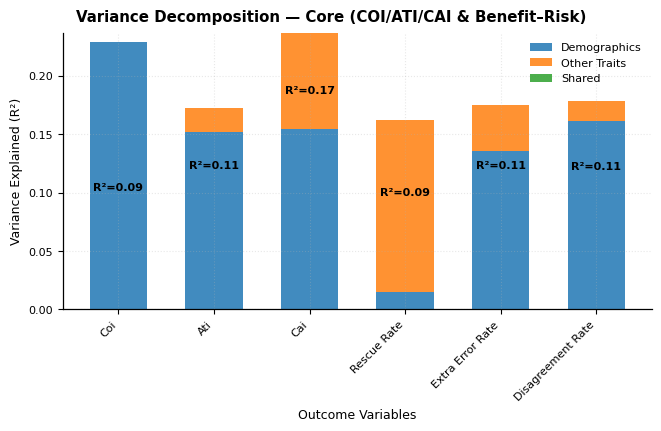

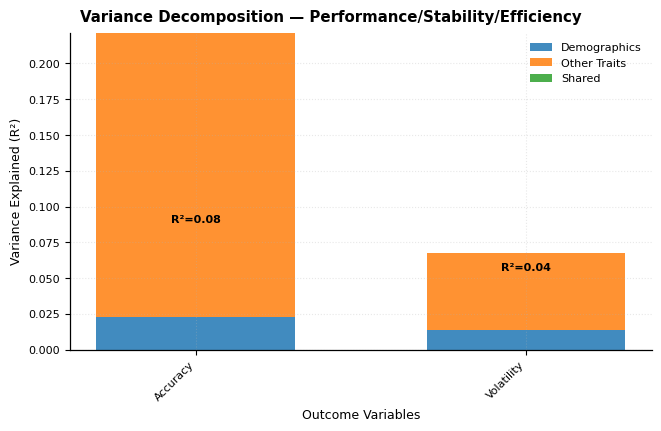

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_zero_shot = run_full_tier3_analysis(merged_df_zero_shot, person_set=PERSON_ETHNICS, 
                                                 case=manipulation_case,
                                                plots_root="results/figs",
                                                strategy="few_shot", 
                                                stage="tier3",         
                                                per_figure_subdirs={
                                                    "consistency_boldness": "consistency",
                                                    "predictive": "predictive_model",
                                                },
                                                save=True)




# Few-shot  
## Analysis results few-shot - manipulation detection

In [ ]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_few_shot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case,
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pr

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary_few_shot = run_full_preliminary_analysis(merged_df_few_shot, 
                                                    case=manipulation_case,
                                                    df=sample_mentalmanip, 
                                                    person_set=PERSON_ETHNICS,
                                                    plots_root="results/figs",
                                                    strategy="few_shot",
                                                    stage="preliminary",
                                                    per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Indian vs White                     Δ = -0.7 pp
 2. Age Age 1 vs Age 2                  Δ = -0.6 pp
 3. Age Age 2 vs Age 3                  Δ = +0.6 pp
 4. Age Age 1 vs Age 5                  Δ = -0.6 pp
 5. Age Age 3 vs Age 5                  Δ = -0.6 pp

Detailed results
[—] man_vs_woman                        | Man: 0.673 | Woman: 0.670
         Δ = +0.3 pp   95% CI [-0.3, +0.8] pp   h = +0.006
[—] asian_vs_black                      | Asian: 0.671 | Black: 0.673
         Δ = -0.2 pp   95% CI [-1.0, +0.5] pp   h = -0.005
[—] asian_vs_indian        

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1_few_shot = run_full_tier1_analysis(merged_df_few_shot, 
                                       case=manipulation_case, 
                                       group_keys=("gender", "ethnicity"), 
                                       person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="few_shot", 
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=30,000 | n_items=500 | n_profiles=60
Clustered on: sample_id (n_clusters=500)

-- Block Wald tests --
   - main:C(gender): F(1, 499)=0.133, p=0.7153
   - main:C(ethnicity): F(5, 499)=0.478, p=0.7926
   - inter:C(gender):C(ethnicity): F(5, 499)=0.0199, p=0.9998

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=30,000, n_profiles=60, n_items=500
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 0.133211    1 499.0 0.715280
      

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier2_few_shot = run_full_tier2_analysis(
    merged_df=merged_df_few_shot,
    case=manipulation_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="few_shot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
[INFO] Suppressing low-n values in technique (n<50): Intimidation (n=18), Accusation (n=17), Shaming or Belittlement (n=17), Rationalization (n=9), Shaming or Belittlement,Accusation (n=9), Denial (n=5), Intimidation,Persuasion or Seduction (n=4), Rationalization,Persuasion or Seduction (n=4), Brandishing Anger (n=4), Evasion (n=4), Playing Victim Role (n=3), Feigning Innocence (n=3), Shaming or Belittlement,Brandishing Anger (n=3), Rationalization,Intimidation (n=2), Intimidation,Accusation (n=2), Persuasion or Seduction,Accusation (n=2), Accusation,Persuasion or Seduction (n=2), Brandishing Anger,Persuasion or Seduction (n=2), Evasion,Accusation (n=1), Rationalization,Shaming or Belittlement,Accusation (n=1), Shaming or Belittlement,Pe

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[Selection gap] Δacc(dev) − Δacc(test): +0.0013

=== Cost/Efficiency Pareto (TEST) ===
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum un

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


2. Cluster Analysis...
4. System-Level Recommendations...

Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Ensemble (selected on DEV): man_white
   • TEST Δacc vs baseline: +0.0131 [95% CI -0.0327, +0.0588] | McNemar p=0.7905
   • Selection gap (DEV − TEST Δacc): +0.0013
   • Pareto (TEST) recommendation: woman_asian | acc=0.686, extra=0.040, tokens=5
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.053, p=0.6859, q=0.6889 
  Consistency vs Boldness: r=-0.053, p=0.6889 
  Volatility vs Rescue Rate: r=-0.069, p=0.6018 
  Boldness vs Accuracy: r=-0.075, p=0.5698 

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.121, p=0.5229 
  

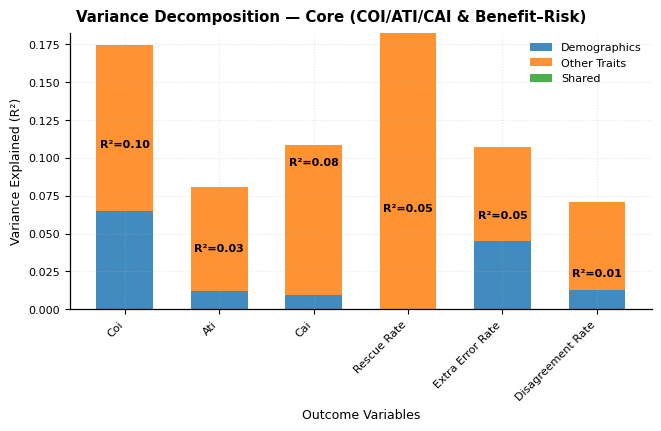

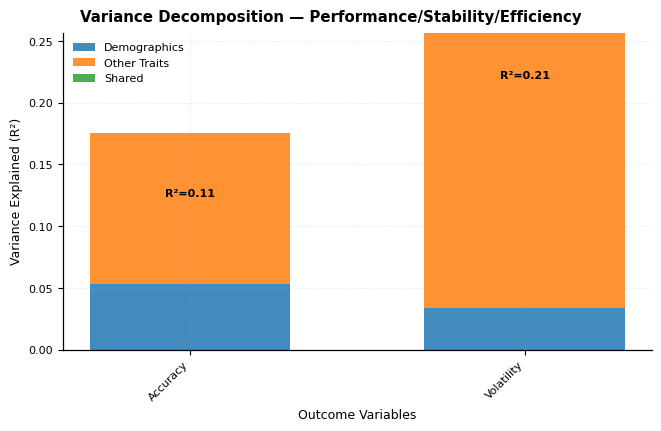

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_few_shot = run_full_tier3_analysis(merged_df_few_shot, person_set=PERSON_ETHNICS, 
                                        case=manipulation_case,
                                        plots_root="results/figs",
                                        strategy="few_shot", 
                                        stage="tier3",         
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)

# Chain-of-Thoughts

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.manipulation_case import manipulation_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_manipulation_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_manipulation_optimized_cot.csv",
    sample_df=sample_mentalmanip,
    case=manipulation_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'technique', 'vulnerability', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pr

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=manipulation_case, df=sample_mentalmanip, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            stage="preliminary",
                                            per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Age Age 1 vs Age 5                  Δ = -1.5 pp
 2. Age Age 2 vs Age 5                  Δ = -1.4 pp
 3. Age Age 4 vs Age 5                  Δ = -1.1 pp
 4. Intersectional White Woman vs Man   Δ = +0.9 pp
 5. Age Age 1 vs Age 3                  Δ = -0.8 pp

Detailed results
[—] man_vs_woman                        | Man: 0.574 | Woman: 0.575
         Δ = -0.1 pp   95% CI [-0.5, +0.3] pp   h = -0.002
[—] asian_vs_black                      | Asian: 0.577 | Black: 0.571
         Δ = +0.6 pp   95% CI [-0.1, +1.4] pp   h = +0.013
[—] asian_vs_indian        

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=manipulation_case, person_set=PERSON_ETHNICS,
                                            figures=True,
                                            plots_root="results/figs",
                                            strategy="cot", 
                                            stage="tier1",
                                            per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})



=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=30,000 | n_items=500 | n_profiles=60
Clustered on: sample_id (n_clusters=500)

-- Block Wald tests --
   - main:C(gender): F(1, 499)=3.39, p=0.06627
   - inter:C(gender):C(ethnicity): F(5, 499)=1.17, p=0.3208
   - main:C(ethnicity): F(5, 499)=0.77, p=0.5717

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=30,000, n_profiles=60, n_items=500
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 3.387819    1 499.0 0.066273
inter:C(g

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=manipulation_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="cot",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
Category columns from CaseConfig: ['technique', 'vulnerability']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (500, 309)
[INFO] Suppressing low-n values in technique (n<50): Intimidation (n=18), Accusation (n=17), Shaming or Belittlement (n=17), Rationalization (n=9), Shaming or Belittlement,Accusation (n=9), Denial (n=5), Intimidation,Persuasion or Seduction (n=4), Rationalization,Persuasion or Seduction (n=4), Brandishing Anger (n=4), Evasion (n=4), Playing Victim Role (n=3), Feigning Innocence (n=3), Shaming or Belittlement,Brandishing Anger (n=3), Rationalization,Intimidation (n=2), Intimidation,Accusation (n=2), Persuasion or Seduction,Accusation (n=2), Accusation,Persuasion or Seduction (n=2), Brandishing Anger,Persuasion or Seduction (n=2), Evasion,Accusation (n=1), Rationalization,Shaming or Belittlement,Accusation (n=1), Shaming or Belittlement,Pe

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[Selection gap] Δacc(dev) − Δacc(test): +0.0079

=== Cost/Efficiency Pareto (TEST) ===
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum unavailable; using n_profiles as a proxy for token cost.
[Pareto] tokens_per_sample_sum un

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


2. Cluster Analysis...
4. System-Level Recommendations...

Completed! Created 3 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Ensemble (selected on DEV): man_asian
   • TEST Δacc vs baseline: +0.0065 [95% CI -0.0327, +0.0458] | McNemar p=1
   • Selection gap (DEV − TEST Δacc): +0.0079
   • Pareto (TEST) recommendation: man_black | acc=0.575, extra=0.024, tokens=5
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.381, p=0.0026, q=0.0033 ***
  Consistency vs Boldness: r=-0.380, p=0.0028 ***
  Volatility vs Rescue Rate: r=0.313, p=0.0149 ***
  Boldness vs Accuracy: r=0.418, p=0.0009 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.423, p=

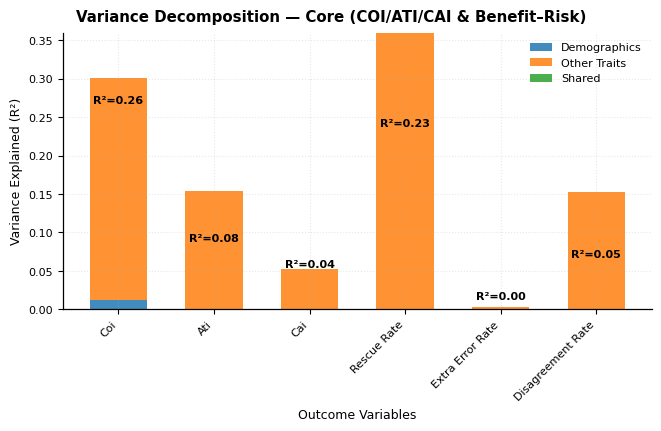

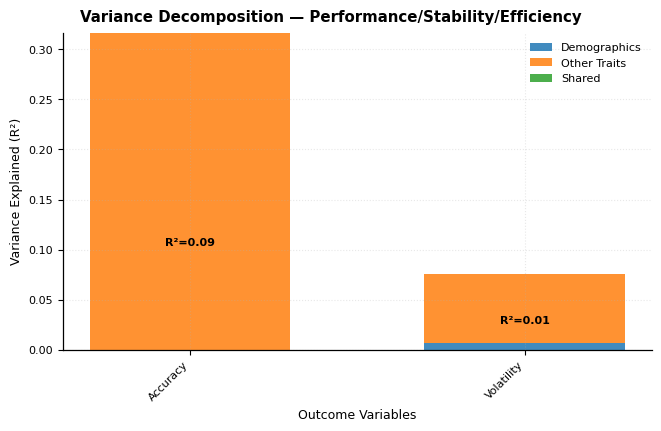

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.manipulation_case import manipulation_case

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=manipulation_case,
                                        plots_root="results/figs",
                                        strategy="cot", 
                                        stage="tier3",       
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)
